In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
apps = pd.read_csv("/content/apps.csv")

reviews = pd.read_csv("/content/user_reviews.csv")

apps.head()
reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [ ]:
print(apps.info())

print(apps.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9659 non-null   int64  
 1   App             9659 non-null   object 
 2   Category        9659 non-null   object 
 3   Rating          8196 non-null   float64
 4   Reviews         9659 non-null   int64  
 5   Size            8432 non-null   float64
 6   Installs        9659 non-null   object 
 7   Type            9659 non-null   object 
 8   Price           9659 non-null   object 
 9   Content Rating  9659 non-null   object 
 10  Genres          9659 non-null   object 
 11  Last Updated    9659 non-null   object 
 12  Current Ver     9651 non-null   object 
 13  Android Ver     9657 non-null   object 
dtypes: float64(2), int64(2), object(10)
memory usage: 1.0+ MB
None
Unnamed: 0           0
App                  0
Category             0
Rating            1463
Reviews      

In [ ]:
apps.drop_duplicates(inplace=True)

reviews.drop_duplicates(inplace=True)

In [ ]:
apps['Rating'].fillna(
    apps['Rating'].mean(),
    inplace=True
)

reviews.dropna(inplace=True)

/tmp/ipykernel_5859/1238955814.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  apps['Rating'].fillna(


In [ ]:
apps['Installs'] = (
    apps['Installs']
    .str.replace('+','', regex=False)
    .str.replace(',','', regex=False)
)

apps['Installs'] = apps['Installs'].astype(int)

In [ ]:

apps['Price'] = (
    apps['Price']
    .str.replace('$','', regex=False)
)

apps['Price'] = apps['Price'].astype(float)

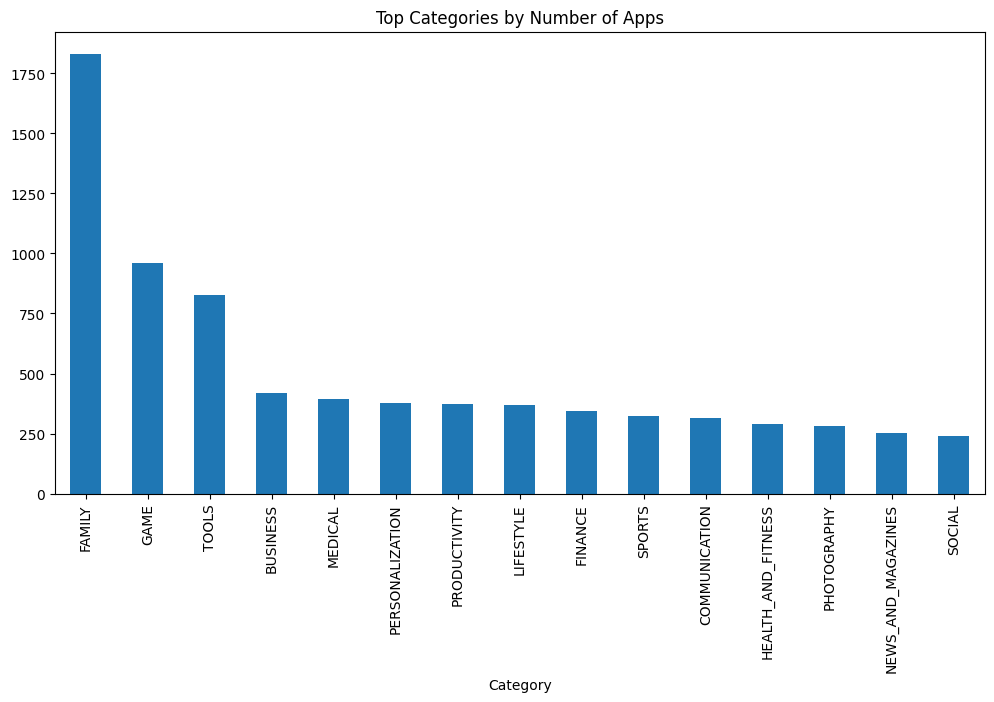

In [ ]:
plt.figure(figsize=(12,6))

apps['Category'].value_counts()\
    .head(15)\
    .plot(kind='bar')

plt.title("Top Categories by Number of Apps")

plt.show()

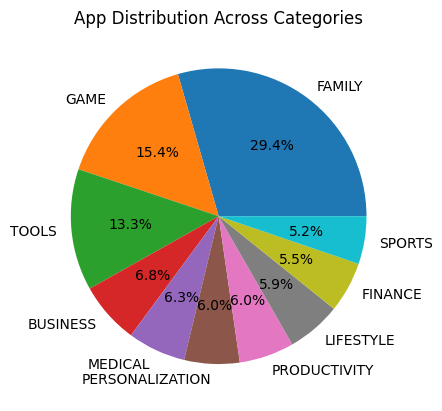

In [ ]:
apps['Category'].value_counts()\
    .head(10)\
    .plot(
        kind='pie',
        autopct='%1.1f%%'
    )

plt.ylabel('')

plt.title("App Distribution Across Categories")

plt.show()

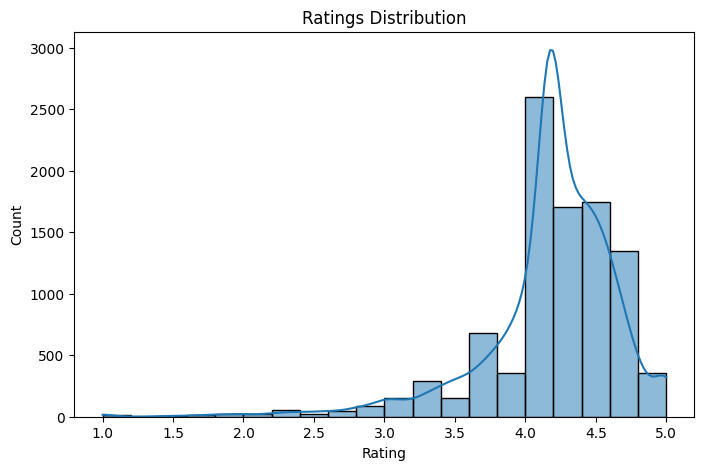

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    apps['Rating'],
    bins=20,
    kde=True
)

plt.title("Ratings Distribution")

plt.show()

In [ ]:
top_ratings = apps.groupby(
    'Category'
)['Rating'].mean().sort_values(
    ascending=False
)

print(top_ratings.head(10))

Category
EDUCATION              4.362800
EVENTS                 4.357682
ART_AND_DESIGN         4.348746
BOOKS_AND_REFERENCE    4.303972
PERSONALIZATION        4.299237
PARENTING              4.278874
BEAUTY                 4.256711
GAME                   4.243736
WEATHER                4.236870
SOCIAL                 4.236137
Name: Rating, dtype: float64


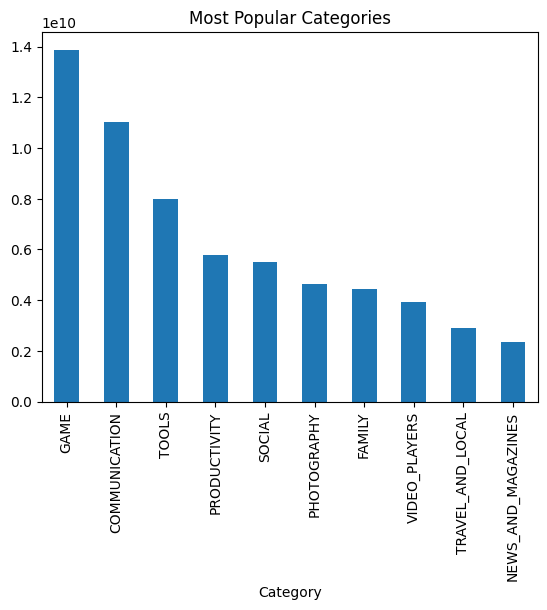

In [ ]:
popular = apps.groupby(
    'Category'
)['Installs'].sum().sort_values(
    ascending=False
)

popular.head(10).plot(
    kind='bar'
)

plt.title("Most Popular Categories")

plt.show()

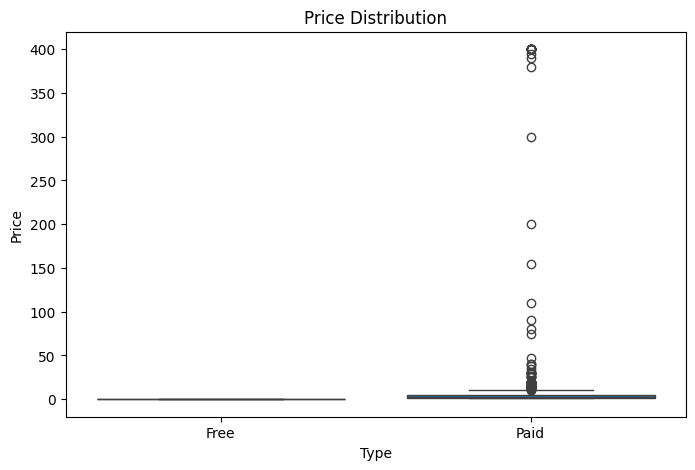

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Type',
    y='Price',
    data=apps
)

plt.title("Price Distribution")

plt.show()

In [ ]:
def convert_size(size):

    if 'M' in str(size):
        return float(size.replace('M',''))

    elif 'k' in str(size):
        return float(size.replace('k',''))/1024

    else:
        return np.nan

apps['Size'] = apps['Size'].apply(
    convert_size
)

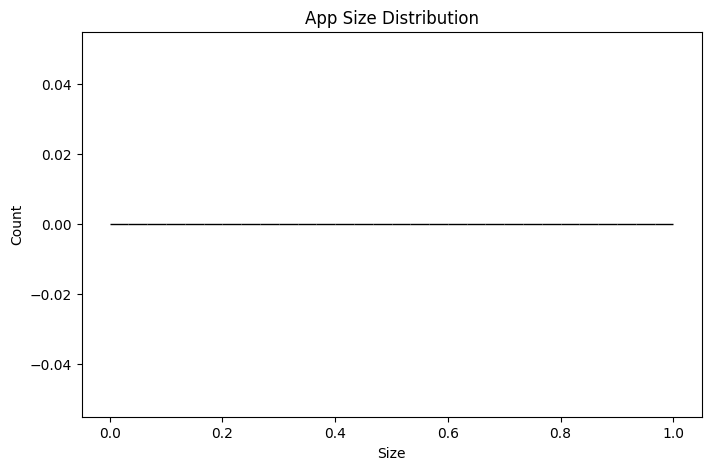

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    apps['Size'],
    bins=30
)

plt.title("App Size Distribution")

plt.show()

In [ ]:
reviews['Sentiment'].value_counts()

,count
Sentiment,
Positive,19015
Negative,6321
Neutral,4356


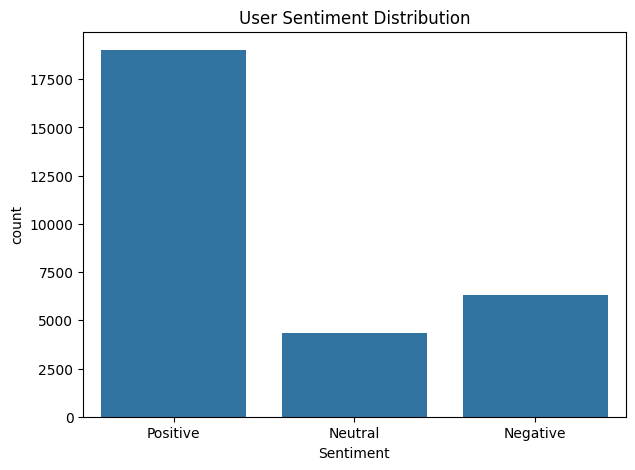

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='Sentiment',
    data=reviews
)

plt.title("User Sentiment Distribution")

plt.show()

In [ ]:
print(
    reviews[
        'Sentiment_Polarity'
    ].mean()
)

0.18886801909094042


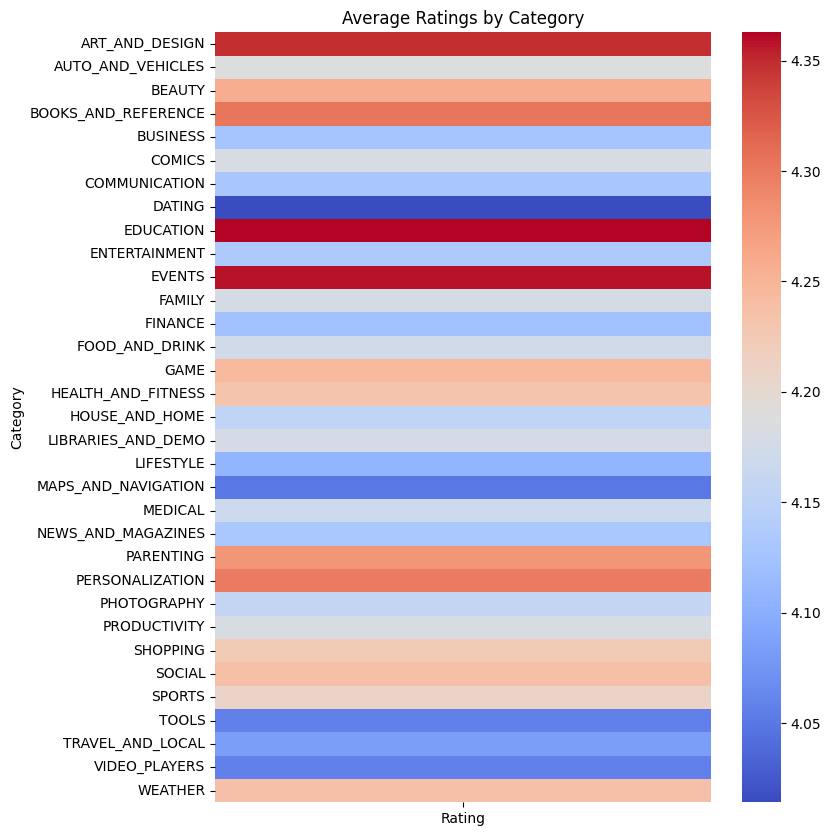

In [ ]:
pivot = apps.pivot_table(
    values='Rating',
    index='Category',
    aggfunc='mean'
)

plt.figure(figsize=(8,10))

sns.heatmap(
    pivot,
    cmap='coolwarm'
)

plt.title("Average Ratings by Category")

plt.show()

In [ ]:
top_apps = apps[
    ['App',
     'Installs',
     'Rating']
]

top_apps.sort_values(
    by='Installs',
    ascending=False
).head(10)

,App,Installs,Rating
2977,Google News,1000000000,3.9
2012,Google+,1000000000,4.2
1356,Subway Surfers,1000000000,4.5
152,Google Play Books,1000000000,3.9
2908,YouTube,1000000000,4.3
2003,Instagram,1000000000,4.5
2930,Google Play Movies & TV,1000000000,3.7
2191,Google Photos,1000000000,4.5
2429,Google Street View,1000000000,4.2
701,Google Play Games,1000000000,4.3
